# 2. Data Preparation and Cleaning

## Overview

This notebook transforms the harmonized BRFSS dataset into an analysis-ready format suitable for statistical analysis and machine learning. The raw data contains response codes, missing values, and categorical variables that require systematic cleaning and recoding.

### Key Objectives

1. **Data Quality Assessment**: Examine distributions, missing values, and data types
2. **Variable Recoding**: Transform multi-level categorical variables into binary indicators
3. **Missing Value Treatment**: Implement systematic imputation strategies
4. **Duplicate Removal**: Identify and remove duplicate survey responses
5. **Final Dataset Creation**: Export cleaned data for downstream analysis

### Workflow Summary

```
Harmonized Data → Recode Variables → Handle Missing Values → Remove Duplicates → Export Clean Dataset
```

### Input/Output Files

**Input**: 
- `BRFSS_2015_2024_harmonized.zip` (Harmonized dataset from Notebook 1)

**Output**:
- `BRFSS_2015_2024_cleaned.zip` (Analysis-ready dataset with binary encodings)
- `BRFSS_2015_2024_recoded.zip` (Dataset with human-readable labels)

---

## 2.1 Import Required Libraries

Import necessary Python libraries for data manipulation, visualization, and statistical analysis.

In [1]:
from pathlib import Path
from typing import Union, Optional, Dict, List, Tuple
import pandas as pd
import numpy as np
import logging
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

## 2.2 Configuration and File Paths

Define paths for input/output files and configuration mappings.

**Key File Paths**:
- **BRFSS_HARMONIZED_ZIP**: Input file from Notebook 1 (harmonized variable names)
- **BRFSS_CLEAN_ZIP**: Output file with binary/numeric encodings for modeling
- **BRFSS_RECODED_ZIP**: Output file with human-readable text labels
- **RECODE_MAP_FILE**: JSON file defining recoding rules
- **RECODED_CONFIG_FILE**: JSON file with text label mappings

**Note**: The Notebook 1 produces *harmonized* (not yet cleaned) data

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_HARMONIZED_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024.zip"
BRFSS_HARMONIZED_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
BRFSS_HARMONIZED_RECODED_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_recoded.zip"
RECODE_MAP_FILE = CONFIG_DIR / "recode_mappings.json"
RECODED_CONFIG_FILE = CONFIG_DIR / "VALUE_RECODED_TEXT_MAP.json"

# Ensure directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 2.3 Utility Functions for Compressed CSV Operations

These utility functions enable efficient reading and writing of CSV files within ZIP archives.

### Functions:

- **`read_zipped_csv()`**: Reads a CSV file directly from a ZIP archive
  - Leverages pandas' native compression support
  - Accepts additional parameters for `read_csv()` (e.g., dtype, parse_dates)

- **`write_df_to_zipped_csv()`**: Writes a DataFrame to a CSV inside a ZIP archive
  - Creates compressed output in a single operation
  - Customizable CSV name within the archive
  - Supports all standard `to_csv()` parameters

**Benefits**:
- Reduces disk space by ~60-70%
- Maintains compatibility with pandas operations
- Simplifies file management

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
def write_df_to_zipped_csv(
    df: pd.DataFrame,
    zip_path: Union[str, Path],
    csv_name: str | None = None,
    **to_csv_kwargs,
) -> None:
    """
    Write a DataFrame to a CSV stored inside a .zip file.

    Parameters
    ----------
    df : pd.DataFrame
        Data to write.
    zip_path : str or Path
        Path to the .zip file to create, e.g. 'data.zip'.
    csv_name : str, optional
        Name of the CSV file inside the zip, e.g. 'data.csv'.
        If None, uses the zip file stem with '.csv'.
    **to_csv_kwargs :
        Extra keyword args passed to DataFrame.to_csv
        (e.g. index=False, sep=',', encoding='utf-8').
    """
    zip_path = Path(zip_path)
    if csv_name is None:
        csv_name = zip_path.stem + ".csv"

    compression_opts = {
        "method": "zip",
        "archive_name": csv_name,
    }

    df.to_csv(
        zip_path,
        header=True,
        compression=compression_opts,
        **to_csv_kwargs,
    )

## 2.4 Load Harmonized Dataset

Load the harmonized BRFSS dataset created in Notebook 1.

**Expected Data Characteristics**:
- **Rows**: ~4,410,255 survey responses
- **Columns**: 19 harmonized variables
- **Data Types**: Mix of int64 and float64 (categorical codes as numbers)
- **Missing Values**: Present as NaN or special codes (7, 9, 77, 88, 99)

**Quality Checks**:
- Verify row count matches expected range
- Confirm all canonical variables are present
- Log initial dataset dimensions

In [5]:
# Load the BRFSS data
df = read_zipped_csv(BRFSS_HARMONIZED_ZIP_FILE)
logging.info(f"Initial data loaded with {df.shape[0]} rows. and columns: {df.shape[1]}")

2026-02-11 00:21:01 - INFO - Initial data loaded with 4410255 rows. and columns: 19


## 2.5 Initial Data Exploration

### 2.5.1 Unique Values Analysis

Examine unique values for each variable to understand:
- Response code ranges
- Special missing value codes (7, 9, 77, 88, 99)
- Data type consistency

**Common BRFSS Response Codes**:
- `7`: "Don't know / Not sure"
- `9`: "Refused"
- `77`: "Don't know / Not sure" (alternate)
- `88`: "None" or "Zero" (context-dependent)
- `99`: "Refused" (alternate)

**Purpose**: Identify which values need recoding or treatment as missing data.

In [6]:
def print_unique_values(data, columnName):
    unique_column_values = data[columnName].unique()
    if pd.api.types.is_numeric_dtype(unique_column_values):
        unique_column_values = np.sort(unique_column_values)
    column_datatype = data[columnName].dtype
    num_unique_column_values = len(unique_column_values)
    logging.info(f'{num_unique_column_values} Unique values in column {columnName} of type {column_datatype}: {unique_column_values}')

In [7]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)
logging.info(f"Data information:\n {df.info()}")
logging.info("Data description:\n")
df.describe().T

2026-02-11 00:21:01 - INFO - 10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2026-02-11 00:21:01 - INFO - 7 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4.  7.  9. nan]
2026-02-11 00:21:01 - INFO - 14 Unique values in column AGE_CATEGORIES of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
2026-02-11 00:21:02 - INFO - 5 Unique values in column SEX of type float64: [ 1.  2.  7.  9. nan]
2026-02-11 00:21:02 - INFO - 10 Unique values in column RACE of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
2026-02-11 00:21:02 - INFO - 7 Unique values in column INCOME of type float64: [ 1.  2.  3.  4.  5.  9. nan]
2026-02-11 00:21:02 - INFO - 5 Unique values in column EDUCATION_LEVEL of type float64: [1. 2. 3. 4. 9.]
2026-02-11 00:21:02 - INFO - 10 Unique values in column EMPLOYMENT of type float64: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. nan]
2026-02-11 00:21:02 - INFO - 8 Unique values in column MA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410255 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             float64
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            float64
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   float64
 14  SMOKER                     float64
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              float64
 17  POOR_PHYSICAL_HEALTH_DAYS  float64
 18  POOR_MENTAL_HEALTH_DAYS    float64
dtypes: float64(18), int64(1)
memory usage: 639

,count,mean,std,min,25%,50%,75%,max
YEAR,4410255.0,2019.470309,2.905843,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,4410187.0,2.750988,0.744697,1.0,3.0,3.0,3.0,9.0
AGE_CATEGORIES,4410255.0,7.772692,3.620983,1.0,5.0,8.0,11.0,14.0
SEX,3050390.0,1.555347,0.541623,1.0,1.0,2.0,2.0,9.0
RACE,4410162.0,2.157547,2.402617,1.0,1.0,1.0,2.0,9.0
INCOME,4045749.0,4.498346,2.090601,1.0,3.0,5.0,5.0,9.0
EDUCATION_LEVEL,4410255.0,3.019977,1.044030,1.0,2.0,3.0,4.0,9.0
EMPLOYMENT,4387101.0,3.905136,2.882087,1.0,1.0,3.0,7.0,9.0
MARITAL_STATUS,4410112.0,2.365037,1.772194,1.0,1.0,1.0,3.0,9.0
HEALTH_CARE_COVERAGE,4410255.0,4.139525,3.849049,1.0,1.0,1.0,9.0,9.0


## 2.6 Variable Recoding

### Recoding Strategy

Transform multi-level categorical variables into binary (0/1) or simplified ordinal scales suitable for statistical modeling.

### Recoding Rules (from `recode_mappings.json`)

#### Binary Outcomes
- **DIABETES**: `3,2` → `0` (No/Gestational), `1,4` → `1` (Yes/Pre-diabetes)
- **SEX**: `2` → `0` (Female), `1` → `1` (Male)
- **EXERCISE**: `2` → `0` (No), `1` → `1` (Yes)
- **SMOKER**: Multi-step recoding to `0` (Never/Former) vs `1` (Current)
- **HEALTHSTATUS**: `1-3` → `1` (Good), `4-5` → `0` (Poor)

#### Ordinal Scales
- **AGECATEGORIES**: Shift to 0-indexed (13 categories: 0=18-24, 12=80+)
- **BMICAT**: `1` → `0` (Underweight), `2` → `1` (Normal), `3` → `2` (Overweight), `4` → `3` (Obese)
- **INCOME**: Normalize to 0-4 scale (0=<$15K, 4=>$50K)
- **EDUCATIONLEVEL**: 0-3 scale (0=Dropout, 3=Graduate degree)

#### Missing Values Treatment
Special codes `7, 9, 77, 88, 99` are converted to `NaN` for subsequent imputation.

### Function: `apply_recode_map()`

Applies the JSON-defined recoding rules to the entire dataset systematically.

In [8]:
def apply_recode_map(df, map_file=RECODE_MAP_FILE, offset=42):
    """
    Apply recoding and missing value handling using the offset method.
    
    The function applies offset to both orig_values and missing_values,
    then replaces:
    - orig_value + offset -> recoded_value
    - missing_value + offset -> NaN
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to recode
    map_file : str
        Path to the recoded_mappings.json file
    offset : int, default=42
        The offset value for safe recoding
    
    Returns:
    --------
    pd.DataFrame
        The recoded dataframe
    """
    with open(map_file, 'r') as f:
        recode_map = json.load(f)
    
    for col_name, mapping in recode_map.items():
        if col_name not in df.columns:
            logging.info(f"  Column {col_name} not found in dataframe, skipping...")
            continue
        
        logging.info(f"Recoding {col_name}...")
        
        orig_values = mapping['orig_values']
        recoded_values = mapping['recoded_values']
        missing_values = mapping.get('missing_values', [])
        
        # Step 1: Add offset to all values in the column
        temp_values = df[col_name] + offset
        
        # Step 2: Create offset mapping
        # Map: (orig_value + offset) -> recoded_value
        offset_mapping = {
            orig + offset: recoded 
            for orig, recoded in zip(orig_values, recoded_values)
        }
        
        # Map: (missing_value + offset) -> NaN
        for missing_val in missing_values:
            offset_mapping[missing_val + offset] = np.nan
        
        # Step 3: Apply the offset mapping
        df[col_name] = temp_values.map(offset_mapping)
        
        # Report results
        num_recoded = len(orig_values)
        num_missing = len(missing_values)
        num_unmapped = df[col_name].isna().sum()
        logging.info(f"    Recoded {num_recoded} values, set {num_missing} value types to NaN")
        logging.info(f"  Total NaN values in column: {num_unmapped}")
    
    return df

df = apply_recode_map(df)

2026-02-11 00:21:04 - INFO - Recoding DIABETES...
2026-02-11 00:21:05 - INFO -     Recoded 4 values, set 2 value types to NaN
2026-02-11 00:21:05 - INFO -   Total NaN values in column: 9064
2026-02-11 00:21:05 - INFO - Recoding AGE_CATEGORIES...
2026-02-11 00:21:05 - INFO -     Recoded 13 values, set 1 value types to NaN
2026-02-11 00:21:05 - INFO -   Total NaN values in column: 76326
2026-02-11 00:21:05 - INFO - Recoding SEX...
2026-02-11 00:21:05 - INFO -     Recoded 2 values, set 2 value types to NaN
2026-02-11 00:21:05 - INFO -   Total NaN values in column: 1362770
2026-02-11 00:21:05 - INFO - Recoding RACE...
2026-02-11 00:21:05 - INFO -     Recoded 7 values, set 1 value types to NaN
2026-02-11 00:21:05 - INFO -   Total NaN values in column: 186412
2026-02-11 00:21:05 - INFO - Recoding INCOME...
2026-02-11 00:21:05 - INFO -     Recoded 5 values, set 1 value types to NaN
2026-02-11 00:21:05 - INFO -   Total NaN values in column: 836353
2026-02-11 00:21:05 - INFO - Recoding EDUCATIO

Looks like there is significant number of NaNs in each column

In [9]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)
logging.info(f"Data information:\n {df.info()}")
logging.info("Data description:\n")
df.describe().T

2026-02-11 00:21:06 - INFO - 10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2026-02-11 00:21:06 - INFO - 5 Unique values in column DIABETES of type float64: [ 0.  1.  2.  3. nan]
2026-02-11 00:21:06 - INFO - 14 Unique values in column AGE_CATEGORIES of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. nan]
2026-02-11 00:21:06 - INFO - 3 Unique values in column SEX of type float64: [ 0.  1. nan]
2026-02-11 00:21:06 - INFO - 8 Unique values in column RACE of type float64: [ 0.  1.  2.  3.  4.  5.  7. nan]
2026-02-11 00:21:06 - INFO - 6 Unique values in column INCOME of type float64: [ 0.  1.  2.  3.  4. nan]
2026-02-11 00:21:06 - INFO - 5 Unique values in column EDUCATION_LEVEL of type float64: [ 0.  1.  2.  3. nan]
2026-02-11 00:21:06 - INFO - 9 Unique values in column EMPLOYMENT of type float64: [ 0.  1.  2.  3.  4.  5.  6.  7. nan]
2026-02-11 00:21:06 - INFO - 7 Unique values in column MARITAL_STATUS of type float64:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410255 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             float64
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            float64
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   float64
 14  SMOKER                     float64
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              float64
 17  POOR_PHYSICAL_HEALTH_DAYS  float64
 18  POOR_MENTAL_HEALTH_DAYS    float64
dtypes: float64(18), int64(1)
memory usage: 639

,count,mean,std,min,25%,50%,75%,max
YEAR,4410255.0,2019.470309,2.905843,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,4401191.0,0.458226,1.051746,0.0,0.0,0.0,0.0,3.0
AGE_CATEGORIES,4333929.0,6.663021,3.556324,0.0,4.0,7.0,10.0,12.0
SEX,3047485.0,0.451217,0.497615,0.0,0.0,0.0,1.0,1.0
RACE,4223843.0,0.899002,2.097827,0.0,0.0,0.0,0.0,7.0
INCOME,3573902.0,2.904012,1.385254,0.0,2.0,4.0,4.0,4.0
EDUCATION_LEVEL,4390071.0,1.992483,0.964281,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,4344589.0,5.401515,1.817153,0.0,5.0,6.0,7.0,7.0
MARITAL_STATUS,4371864.0,3.383812,1.933014,0.0,2.0,5.0,5.0,5.0
HEALTH_CARE_COVERAGE,2714491.0,0.896852,0.304152,0.0,1.0,1.0,1.0,1.0


In [10]:
# Drop rows where DIABETES is NaN
logging.info("Dropping rows with missing DIABETES values.")
initial_row_count = df.shape[0]
df.dropna(subset=['DIABETES'], inplace=True)
logging.info(f"Data after dropping missing DIABETES has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} rows).")
logging.info("Data info after dropping missing DIABETES values:")
logging.info(df.info())
logging.info("Data description:\n")
df.describe().T

2026-02-11 00:21:10 - INFO - Dropping rows with missing DIABETES values.
2026-02-11 00:21:10 - INFO - Data after dropping missing DIABETES has 4401191 rows (dropped 9064 rows).
2026-02-11 00:21:10 - INFO - Data info after dropping missing DIABETES values:
2026-02-11 00:21:10 - INFO - None
2026-02-11 00:21:10 - INFO - Data description:



<class 'pandas.core.frame.DataFrame'>
Index: 4401191 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   YEAR                       int64  
 1   DIABETES                   float64
 2   AGE_CATEGORIES             float64
 3   SEX                        float64
 4   RACE                       float64
 5   INCOME                     float64
 6   EDUCATION_LEVEL            float64
 7   EMPLOYMENT                 float64
 8   MARITAL_STATUS             float64
 9   HEALTH_CARE_COVERAGE       float64
 10  BMICAT                     float64
 11  HEART_ATTACK               float64
 12  STROKE                     float64
 13  EXERCISE                   float64
 14  SMOKER                     float64
 15  HEAVY_ALCOHOL_CONSUMPTION  float64
 16  HEALTH_STATUS              float64
 17  POOR_PHYSICAL_HEALTH_DAYS  float64
 18  POOR_MENTAL_HEALTH_DAYS    float64
dtypes: float64(18), int64(1)
memory usage: 671.6 MB

,count,mean,std,min,25%,50%,75%,max
YEAR,4401191.0,2019.469706,2.905856,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,4401191.0,0.458226,1.051746,0.0,0.0,0.0,0.0,3.0
AGE_CATEGORIES,4326572.0,6.663148,3.555984,0.0,4.0,7.0,10.0,12.0
SEX,3041621.0,0.451062,0.497599,0.0,0.0,0.0,1.0,1.0
RACE,4216643.0,0.897671,2.096523,0.0,0.0,0.0,0.0,7.0
INCOME,3569207.0,2.905086,1.384743,0.0,2.0,4.0,4.0,4.0
EDUCATION_LEVEL,4382039.0,1.993047,0.964000,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,4336807.0,5.402433,1.816464,0.0,5.0,6.0,7.0,7.0
MARITAL_STATUS,4364056.0,3.384585,1.932794,0.0,2.0,5.0,5.0,5.0
HEALTH_CARE_COVERAGE,2710153.0,0.897066,0.303873,0.0,1.0,1.0,1.0,1.0


In [11]:
# Drop duplicate rows
logging.info("Dropping duplicate rows from the dataset.")
initial_row_count = df.shape[0]
df.drop_duplicates(inplace=True)
logging.info(f"Data after dropping duplicates has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} duplicates).")
logging.info("Data description:\n")
df.describe().T

2026-02-11 00:21:13 - INFO - Dropping duplicate rows from the dataset.
2026-02-11 00:21:16 - INFO - Data after dropping duplicates has 3101950 rows (dropped 1299241 duplicates).
2026-02-11 00:21:16 - INFO - Data description:



,count,mean,std,min,25%,50%,75%,max
YEAR,3101950.0,2019.469482,2.900146,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,3101950.0,0.586484,1.155830,0.0,0.0,0.0,0.0,3.0
AGE_CATEGORIES,3039177.0,6.645169,3.594335,0.0,4.0,7.0,10.0,12.0
SEX,2172537.0,0.440492,0.496446,0.0,0.0,0.0,1.0,1.0
RACE,2931246.0,1.170616,2.329323,0.0,0.0,0.0,1.0,7.0
INCOME,2450147.0,2.550537,1.447042,0.0,1.0,3.0,4.0,4.0
EDUCATION_LEVEL,3083955.0,1.815675,0.975382,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,3044645.0,5.129752,1.968014,0.0,5.0,5.0,7.0,7.0
MARITAL_STATUS,3067193.0,3.093624,1.954681,0.0,2.0,3.0,5.0,5.0
HEALTH_CARE_COVERAGE,1893344.0,0.857731,0.349326,0.0,1.0,1.0,1.0,1.0


In [12]:
def impute_missing_values_iterative(df: pd.DataFrame,
                                     max_iter: int = 10,
                                     random_state: int = 42,
                                     verbose: bool = True) -> Tuple[pd.DataFrame, Dict]:
    """
    Impute missing values using sklearn's IterativeImputer (MICE algorithm).

    IterativeImputer uses a round-robin approach:
    - Models each feature with missing values as a function of other features
    - Iteratively predicts missing values using other features
    - More sophisticated than KNN, considers feature relationships
    - Based on MICE (Multivariate Imputation by Chained Equations)

    This is the most advanced sklearn method but requires more computation.

    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe after recoding, dropping DIABETES missing rows, 
        and removing duplicates
    max_iter : int, default=10
        Maximum number of imputation rounds
    random_state : int, default=42
        Random seed for reproducibility
    verbose : bool, default=True
        If True, prints detailed imputation statistics

    Returns:
    --------
    pd.DataFrame
        DataFrame with imputed values
    dict
        Dictionary containing imputation statistics
    """
    df = df.copy()

    if verbose:
        logging.info("=" * 80)
        logging.info("MISSING VALUE IMPUTATION - ITERATIVE IMPUTER (MICE)")
        logging.info("=" * 80)
        logging.info(f"Dataset shape: {df.shape}")
        logging.info(f"Maximum iterations: {max_iter}\n")

        # Show initial missing values
        missing_before = df.isnull().sum()
        missing_fields = missing_before[missing_before > 0]
        if len(missing_fields) > 0:
            logging.info("Missing values before imputation:")
            total_missing = 0
            for field in missing_fields.index:
                count = missing_fields[field]
                pct = count / len(df) * 100
                total_missing += count
                logging.info(f"  {field:30s}: {count:6d} ({pct:5.2f}%)")
            logging.info(f"  Total missing values: {total_missing}\n")

    # Store column names and order
    columns = df.columns.tolist()

    # Initialize Iterative Imputer
    imputer = IterativeImputer(
        max_iter=max_iter,
        random_state=random_state,
        verbose=0,  # Suppress sklearn's verbose output
        add_indicator=False
    )

    if verbose:
        logging.info("Fitting Iterative Imputer and imputing values...")
        logging.info(f"  Method: MICE (Multivariate Imputation by Chained Equations)")
        logging.info(f"  Features modeled iteratively using other features")
        logging.info("")

    # Fit and transform
    df_imputed_array = imputer.fit_transform(df)

    # Convert back to DataFrame
    df_imputed = pd.DataFrame(df_imputed_array, columns=columns, index=df.index)

    # Round to integers and clip to valid ranges
    df_imputed = df_imputed.round()

    # Ensure non-negative values (all our codes are non-negative)
    df_imputed = df_imputed.clip(lower=0).astype(int)

    # Calculate imputation statistics
    imputation_stats = {}
    missing_before = df.isnull().sum()

    for col in columns:
        n_imputed = missing_before[col]
        imputation_stats[col] = {
            'imputed': int(n_imputed),
            'method': 'IterativeImputer'
        }

    if verbose:
        logging.info("=" * 80)
        logging.info("IMPUTATION VALIDATION")
        logging.info("=" * 80)
        logging.info("")

        # Check for remaining missing values
        missing_after = df_imputed.isnull().sum()
        missing_fields = missing_after[missing_after > 0]

        if len(missing_fields) > 0:
            logging.info("  WARNING: Some fields still have missing values:")
            for field in missing_fields.index:
                count = missing_fields[field]
                pct = count / len(df_imputed) * 100
                logging.info(f"  {field}: {count} ({pct:.2f}%)")
            logging.info("")
        else:
            logging.info(" SUCCESS: No missing values remaining!\n")

        # Summary
        total_imputed = sum(stats['imputed'] for stats in imputation_stats.values())
        logging.info(f"Final dataset shape: {df_imputed.shape}")
        logging.info(f"Total values imputed: {total_imputed}\n")

        # Show which fields had imputation
        fields_with_imputation = [k for k, v in imputation_stats.items() if v['imputed'] > 0]
        if fields_with_imputation:
            logging.info("Fields with imputed values:")
            for field in sorted(fields_with_imputation):
                count = imputation_stats[field]['imputed']
                pct = (count / len(df)) * 100
                logging.info(f"  {field:30s}: {count:6d} values ({pct:5.2f}%)")

        logging.info("\n")
        logging.info("=" * 80)

    return df_imputed, imputation_stats

In [13]:
df_imputed, stats = impute_missing_values_iterative(df, max_iter=10)

2026-02-11 00:22:20 - INFO - ================================================================================
2026-02-11 00:22:20 - INFO - MISSING VALUE IMPUTATION - ITERATIVE IMPUTER (MICE)
2026-02-11 00:22:20 - INFO - ================================================================================
2026-02-11 00:22:20 - INFO - Dataset shape: (3101950, 19)
2026-02-11 00:22:20 - INFO - Maximum iterations: 10

2026-02-11 00:22:21 - INFO - Missing values before imputation:
2026-02-11 00:22:21 - INFO -   AGE_CATEGORIES                :  62773 ( 2.02%)
2026-02-11 00:22:21 - INFO -   SEX                           : 929413 (29.96%)
2026-02-11 00:22:21 - INFO -   RACE                          : 170704 ( 5.50%)
2026-02-11 00:22:21 - INFO -   INCOME                        : 651803 (21.01%)
2026-02-11 00:22:21 - INFO -   EDUCATION_LEVEL               :  17995 ( 0.58%)
2026-02-11 00:22:21 - INFO -   EMPLOYMENT                    :  57305 ( 1.85%)
2026-02-11 00:22:21 - INFO -   MARITAL_STATUS      

In [14]:
# For each column, print unique values
for col in df_imputed.columns:
    print_unique_values(df_imputed, col)
logging.info(f"Data information:\n {df_imputed.info()}")
logging.info("Data description:\n")
df_imputed.describe().T

2026-02-11 00:28:22 - INFO - 10 Unique values in column YEAR of type int32: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2026-02-11 00:28:22 - INFO - 4 Unique values in column DIABETES of type int32: [0 1 2 3]
2026-02-11 00:28:22 - INFO - 16 Unique values in column AGE_CATEGORIES of type int32: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
2026-02-11 00:28:22 - INFO - 2 Unique values in column SEX of type int32: [0 1]
2026-02-11 00:28:22 - INFO - 7 Unique values in column RACE of type int32: [0 1 2 3 4 5 7]
2026-02-11 00:28:22 - INFO - 6 Unique values in column INCOME of type int32: [0 1 2 3 4 5]
2026-02-11 00:28:22 - INFO - 4 Unique values in column EDUCATION_LEVEL of type int32: [0 1 2 3]
2026-02-11 00:28:22 - INFO - 8 Unique values in column EMPLOYMENT of type int32: [0 1 2 3 4 5 6 7]
2026-02-11 00:28:22 - INFO - 6 Unique values in column MARITAL_STATUS of type int32: [0 1 2 3 4 5]
2026-02-11 00:28:22 - INFO - 2 Unique values in column HEALTH_CARE_COVERAGE of type int32: 

<class 'pandas.core.frame.DataFrame'>
Index: 3101950 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype
---  ------                     -----
 0   YEAR                       int32
 1   DIABETES                   int32
 2   AGE_CATEGORIES             int32
 3   SEX                        int32
 4   RACE                       int32
 5   INCOME                     int32
 6   EDUCATION_LEVEL            int32
 7   EMPLOYMENT                 int32
 8   MARITAL_STATUS             int32
 9   HEALTH_CARE_COVERAGE       int32
 10  BMICAT                     int32
 11  HEART_ATTACK               int32
 12  STROKE                     int32
 13  EXERCISE                   int32
 14  SMOKER                     int32
 15  HEAVY_ALCOHOL_CONSUMPTION  int32
 16  HEALTH_STATUS              int32
 17  POOR_PHYSICAL_HEALTH_DAYS  int32
 18  POOR_MENTAL_HEALTH_DAYS    int32
dtypes: int32(19)
memory usage: 248.5 MB


,count,mean,std,min,25%,50%,75%,max
YEAR,3101950.0,2019.469482,2.900146,2015.0,2017.0,2019.0,2022.0,2024.0
DIABETES,3101950.0,0.586484,1.155830,0.0,0.0,0.0,0.0,3.0
AGE_CATEGORIES,3101950.0,6.647309,3.565437,0.0,4.0,7.0,9.0,15.0
SEX,3101950.0,0.406137,0.491111,0.0,0.0,0.0,1.0,1.0
RACE,3101950.0,1.173055,2.272787,0.0,0.0,0.0,1.0,7.0
INCOME,3101950.0,2.529981,1.355815,0.0,1.0,3.0,4.0,5.0
EDUCATION_LEVEL,3101950.0,1.815401,0.973133,0.0,1.0,2.0,3.0,3.0
EMPLOYMENT,3101950.0,5.131696,1.952747,0.0,5.0,5.0,7.0,7.0
MARITAL_STATUS,3101950.0,3.092438,1.945283,0.0,2.0,3.0,5.0,5.0
HEALTH_CARE_COVERAGE,3101950.0,0.913161,0.281599,0.0,1.0,1.0,1.0,1.0


In [15]:
logging.info("First few rows of the dataset:")
df_imputed.head()

2026-02-11 00:28:28 - INFO - First few rows of the dataset:


,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,0,8,0,0,1,1,2,5,1,3,0,0,0,1,0,0,2,2
1,2015,0,6,0,0,0,3,0,2,0,2,0,0,1,3,0,1,0,0
2,2015,0,10,0,0,1,1,5,2,1,1,0,1,0,1,0,0,2,0
3,2015,0,8,0,0,4,1,2,5,1,2,0,0,0,0,0,0,2,2
4,2015,0,8,0,0,2,2,2,5,1,1,0,0,0,0,0,0,2,0


In [16]:
logging.info(f"The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had {df_imputed.shape[0]} rows and {df_imputed.shape[1]} columns.")

2026-02-11 00:28:32 - INFO - The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had 3101950 rows and 19 columns.


In [17]:
logging.info("Write the cleaned dataset to csv")
write_df_to_zipped_csv(df_imputed, BRFSS_HARMONIZED_CLEAN_ZIP_FILE, index=False)

2026-02-11 00:28:38 - INFO - Write the cleaned dataset to csv


In [18]:
def plot_column_as_per_year(df, col, col_year='YEAR'):
    plot_data = pd.crosstab(df[col_year], df[col])
    sns.set_style("whitegrid")
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(12, 7), width=0.75)
    plt.title(f'{col} Distribution Over Years', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total Records', fontsize=12)
    plt.xticks(rotation=0)
    # Generate legend labels from the unique values in the column
    legend_labels = sorted(plot_data.columns.tolist())
    plt.legend(title=col, labels=legend_labels, 
                bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Calculate dynamic threshold based on number of categories
    num_categories = len(plot_data.columns)
    # For many categories, use a lower threshold to ensure labels appear
    threshold = max(1.0, 100 / (num_categories * 5))  # Adjust threshold inversely to number of categories
    
    totals = plot_data.sum(axis=1)
    for container in ax.containers:
        labels = []
        for i, bar in enumerate(container):
            height = bar.get_height()
            year_idx = plot_data.index[i]
            total = totals[year_idx]
            
            # Calculate percentage
            pct = 0
            if total > 0:
                pct = (height / total) * 100
            
            # Create label text
            # Show label if segment is large enough to be readable
            if pct > threshold: 
                labels.append(f'{pct:.1f}%')
            else:
                labels.append('')
        
        # Apply labels to the center of each bar segment
        ax.bar_label(container, labels=labels, label_type='center', 
                        fontsize=10, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

In [19]:
def decode_enum_values(df: pd.DataFrame, 
                       mapping_path: str | Path = RECODED_CONFIG_FILE) -> pd.DataFrame:
    """
    Loads a JSON mapping and replaces encoded values in the DataFrame 
    with their descriptive text labels.
    """
    df_decoded = df.copy()
    mapping_path = Path(mapping_path)
    
    with mapping_path.open("r") as f:
        value_map = json.load(f)

    for col, mapping in value_map.items():
        if col not in df_decoded.columns:
            continue

        # Build the conversion dictionary (handling int vs string keys)
        col_map = {}
        for k, v in mapping.items():
            try:
                col_map[int(k)] = v
            except (ValueError, TypeError):
                col_map[str(k)] = v

        # Apply mapping based on data type
        if pd.api.types.is_numeric_dtype(df_decoded[col]):
            df_decoded[col] = (
                df_decoded[col]
                .dropna()
                .astype(int)
                .map(col_map)
                .reindex(df_decoded.index)
            )
        else:
            df_decoded[col] = df_decoded[col].map(col_map)

    return df_decoded

logging.info("Decoding the enum values and generating a decoded dataframe")
df_imputed_decoded = decode_enum_values(df_imputed, RECODED_CONFIG_FILE)
logging.info(f"Writing the decoded dataframe to csv zip file {BRFSS_HARMONIZED_RECODED_ZIP_FILE}")
write_df_to_zipped_csv(df_imputed_decoded, BRFSS_HARMONIZED_RECODED_ZIP_FILE, index=False)

df_imputed_decoded.head()

2026-02-11 00:30:11 - INFO - Decoding the enum values and generating a decoded dataframe
2026-02-11 00:30:13 - INFO - Writing the decoded dataframe to csv zip file c:\github\brfss-diabetes-trends\data_processed\BRFSS_2015_2024_recoded.zip


,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,No,60-64,Female,White,$15000 - $24999,High School Graduate,Unable to work,Married,Yes,Obese,No,No,No,Former,No,Poor,14+ days,14+ days
1,2015,No,50-54,Female,White,< $15000,Graduate,Unemployed > 1 year,Divorced,No,Overweight,No,No,Yes,Everyday,No,Good,Zero days,Zero days
2,2015,No,70-74,Female,White,$15000 - $24999,High School Graduate,Retired,Divorced,Yes,Normal,No,Yes,No,Former,No,Poor,14+ days,Zero days
3,2015,No,60-64,Female,White,> $50000,High School Graduate,Unable to work,Married,Yes,Overweight,No,No,No,No,No,Poor,14+ days,14+ days
4,2015,No,60-64,Female,White,$25000 - $34999,Undergraduate,Unable to work,Married,Yes,Normal,No,No,No,No,No,Poor,14+ days,Zero days


In [21]:
# For each column, print unique values
for col in df_imputed_decoded.columns:
    print_unique_values(df_imputed_decoded, col)
logging.info(f"Data information:\n {df_imputed_decoded.info()}")
logging.info("Data description:\n")
df_imputed_decoded.describe().T

2026-02-11 00:32:29 - INFO - 10 Unique values in column YEAR of type int32: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2026-02-11 00:32:29 - INFO - 4 Unique values in column DIABETES of type object: ['No' 'Diabetes' 'PreDiabetes' 'Gestational']
2026-02-11 00:32:29 - INFO - 14 Unique values in column AGE_CATEGORIES of type object: ['60-64' '50-54' '70-74' '80+' '65-69' '75-79' '55-59' '35-39' '45-49'
 '25-29' '30-34' '40-44' '18-24' nan]
2026-02-11 00:32:29 - INFO - 2 Unique values in column SEX of type object: ['Female' 'Male']
2026-02-11 00:32:29 - INFO - 7 Unique values in column RACE of type object: ['White' 'Black' 'American Indian' 'Other' 'Hispanic' 'Asian' 'Hawaiian']
2026-02-11 00:32:29 - INFO - 6 Unique values in column INCOME of type object: ['$15000 - $24999' '< $15000' '> $50000' '$25000 - $34999'
 '$35000 - $49999' nan]
2026-02-11 00:32:30 - INFO - 4 Unique values in column EDUCATION_LEVEL of type object: ['High School Graduate' 'Graduate' 'Undergraduate' 'Dropout

<class 'pandas.core.frame.DataFrame'>
Index: 3101950 entries, 0 to 4410254
Data columns (total 19 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   YEAR                       int32 
 1   DIABETES                   object
 2   AGE_CATEGORIES             object
 3   SEX                        object
 4   RACE                       object
 5   INCOME                     object
 6   EDUCATION_LEVEL            object
 7   EMPLOYMENT                 object
 8   MARITAL_STATUS             object
 9   HEALTH_CARE_COVERAGE       object
 10  BMICAT                     object
 11  HEART_ATTACK               object
 12  STROKE                     object
 13  EXERCISE                   object
 14  SMOKER                     object
 15  HEAVY_ALCOHOL_CONSUMPTION  object
 16  HEALTH_STATUS              object
 17  POOR_PHYSICAL_HEALTH_DAYS  object
 18  POOR_MENTAL_HEALTH_DAYS    object
dtypes: int32(1), object(18)
memory usage: 461.5+ MB


,count,mean,std,min,25%,50%,75%,max
YEAR,3101950.0,2019.469482,2.900146,2015.0,2017.0,2019.0,2022.0,2024.0


In [22]:
def sample_rows_by_year(df: pd.DataFrame, 
                       year_col: str = "YEAR", 
                       n_per_year: int = 3, 
                       random_state: int | None = None) -> pd.DataFrame:
    """
    Groups the dataframe by year and samples n rows from each group.
    """
    return (
        df
        .groupby(year_col, group_keys=False)
        .apply(lambda g: g.sample(
            n=min(len(g), n_per_year),
            random_state=random_state
        ))
        .reset_index(drop=True)
    )

df_sampled = sample_rows_by_year(df_imputed_decoded)
df_sampled.head(n=30)

,YEAR,DIABETES,AGE_CATEGORIES,SEX,RACE,INCOME,EDUCATION_LEVEL,EMPLOYMENT,MARITAL_STATUS,HEALTH_CARE_COVERAGE,BMICAT,HEART_ATTACK,STROKE,EXERCISE,SMOKER,HEAVY_ALCOHOL_CONSUMPTION,HEALTH_STATUS,POOR_PHYSICAL_HEALTH_DAYS,POOR_MENTAL_HEALTH_DAYS
0,2015,No,55-59,Male,Black,> $50000,High School Graduate,Wages,Married,Yes,Obese,No,No,No,Former,No,Good,Zero days,Zero days
1,2015,No,55-59,Female,White,$25000 - $34999,Undergraduate,Wages,Divorced,Yes,Overweight,No,No,Yes,No,No,Good,Zero days,1-13 days
2,2015,No,30-34,Male,White,> $50000,Graduate,Wages,Married,Yes,Normal,No,No,Yes,Former,No,Good,1-13 days,1-13 days
3,2016,No,45-49,Female,Hispanic,$15000 - $24999,Graduate,Unemployed > 1 year,Separated,No,Overweight,No,No,No,No,Yes,Good,Zero days,Zero days
4,2016,Diabetes,70-74,Female,Black,$15000 - $24999,Dropout,Student,Widowed,Yes,Obese,No,No,Yes,No,No,Good,14+ days,1-13 days
5,2016,No,25-29,Female,Hispanic,> $50000,Undergraduate,Wages,Partner,Yes,Normal,No,No,Yes,No,No,Good,Zero days,Zero days
6,2017,No,18-24,Female,White,$15000 - $24999,High School Graduate,Wages,Single,Yes,Normal,No,No,Yes,Former,No,Good,Zero days,1-13 days
7,2017,No,18-24,Male,White,> $50000,Graduate,Wages,Married,Yes,Obese,No,No,Yes,Former,No,Good,Zero days,1-13 days
8,2017,No,70-74,Female,Black,< $15000,High School Graduate,Unable to work,Widowed,Yes,Overweight,No,Yes,Yes,Everyday,Yes,Poor,14+ days,1-13 days
9,2018,No,70-74,Male,Black,$25000 - $34999,High School Graduate,Retired,Divorced,Yes,Overweight,No,No,Yes,No,No,Good,Zero days,Zero days


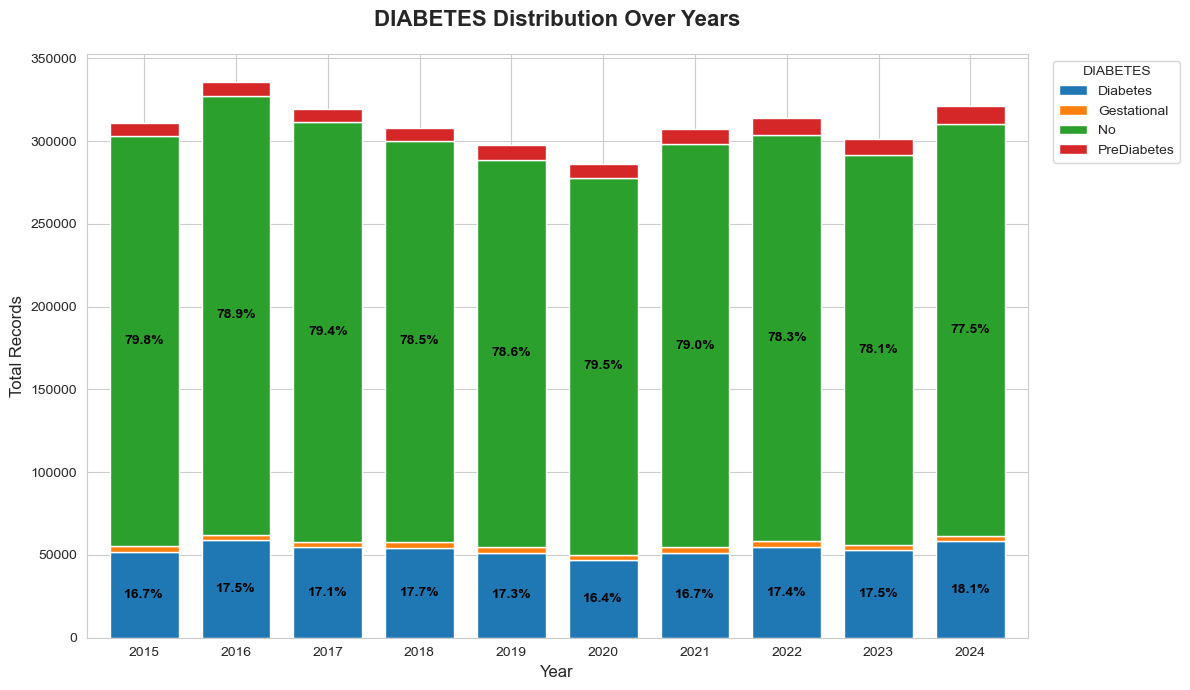

In [23]:
plot_column_as_per_year(df_imputed_decoded, 'DIABETES')

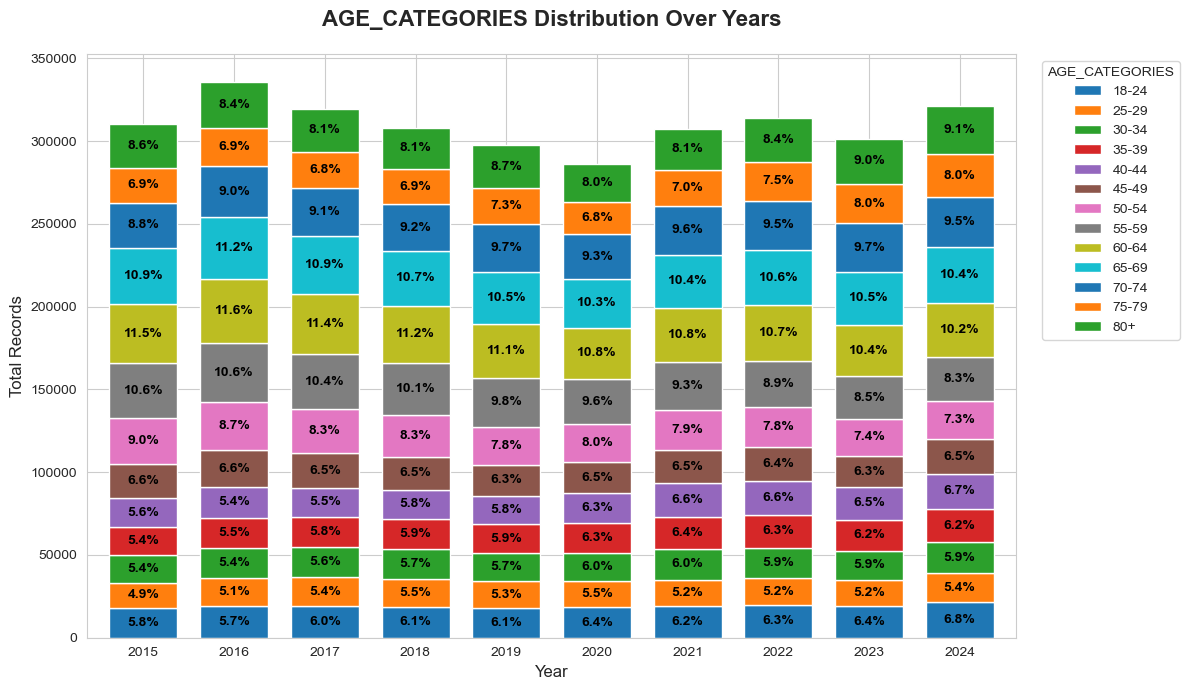

In [24]:
plot_column_as_per_year(df_imputed_decoded, 'AGE_CATEGORIES')